In [1]:
!pip uninstall -y numpy pandas xgboost imbalanced-learn shap scikit-learn numba
!pip install numpy==1.26.4 pandas scikit-learn xgboost imbalanced-learn shap

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 3.0.3
Uninstalling pandas-3.0.3:
  Successfully uninstalled pandas-3.0.3
Found existing installation: xgboost 2.1.4
Uninstalling xgboost-2.1.4:
  Successfully uninstalled xgboost-2.1.4
Found existing installation: imbalanced-learn 0.14.1
Uninstalling imbalanced-learn-0.14.1:
  Successfully uninstalled imbalanced-learn-0.14.1
Found existing installation: shap 0.49.1
Uninstalling shap-0.49.1:
  Successfully uninstalled shap-0.49.1
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: numba 0.65.1
Uninstalling numba-0.65.1:
  Successfully uninstalled numba-0.65.1
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
  Using cached pandas-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached scikit_learn-

In [2]:
!pip install "xgboost<3.0.0"

  Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-macosx_12_0_arm64.whl (1.9 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


NumPy Version Loaded: 1.26.4
XGBoost Version Loaded: 2.1.4
SHAP Version Loaded: 0.49.1
------------------------------
Loading data...
Training shape: (227845, 30), Testing shape: (56962, 30)
Applying SMOTE...
Training XGBoost Classifier...

--- Model Evaluation ---
PR-AUC Score: 0.8669
Macro F1-Score: 0.9087

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Generating SHAP summary plot...


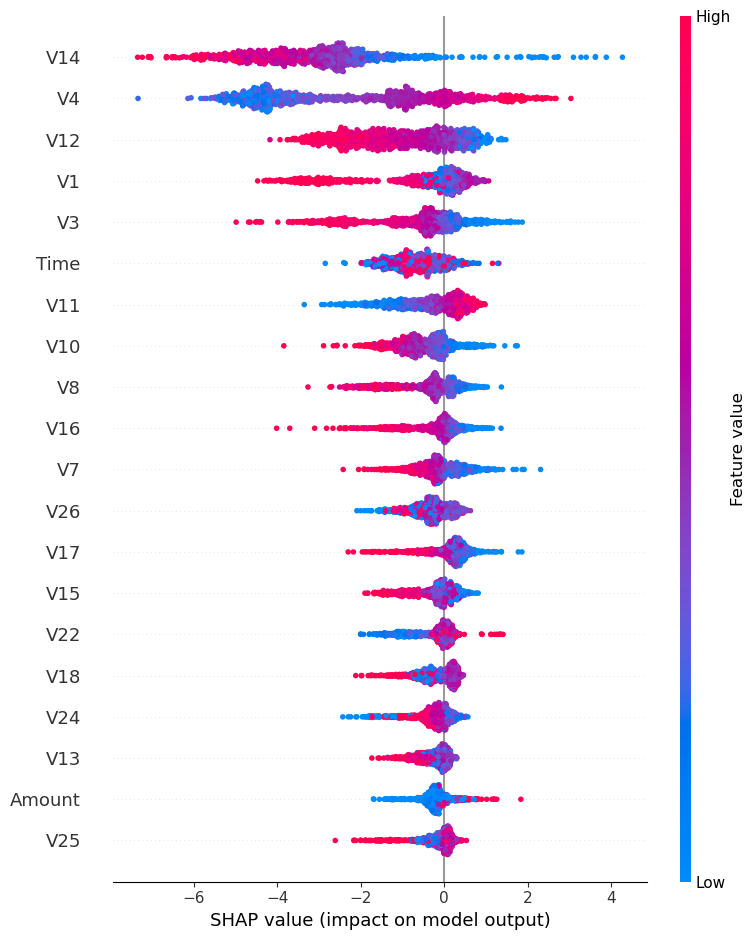

Execution Completed Successfully.


In [3]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, auc, f1_score
from imblearn.over_sampling import SMOTE
import shap

print(f"NumPy Version Loaded: {np.__version__}") 
print(f"XGBoost Version Loaded: {xgb.__version__}")
print(f"SHAP Version Loaded: {shap.__version__}")
print("-" * 30)

try:
    print("Loading data...")
    df = pd.read_csv('creditcard.csv')

    X = df.drop('Class', axis=1)
    y = df['Class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

    print("Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print("Training XGBoost Classifier...")
    scale_weight = sum(y_train_smote == 0) / sum(y_train_smote == 1)

    xgb_model = xgb.XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=42,
        eval_metric='aucpr',
        use_label_encoder=False
    )
    xgb_model.fit(X_train_smote, y_train_smote)

    print("\n--- Model Evaluation ---")
    y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
    y_pred = xgb_model.predict(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall, precision)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print(f"PR-AUC Score: {pr_auc:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Generating SHAP summary plot...")
    sample_X = X_test.sample(1000, random_state=42)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(sample_X)

    shap.summary_plot(shap_values, sample_X)
    print("Execution Completed Successfully.")

except FileNotFoundError:
    print("\nERROR: 'creditcard.csv' not found. Please ensure the dataset is in the same folder as this notebook.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")